Ce notebook permet d'évaluer automatiquement chaque modèle utilisé.

Dans un premier temps, nous avions élaboré une méthode d'évaluation qui s'est avérée mauvaise. Ensuite nous avons décidé d'évaluer autrement, en créant nous-mêmes des métriques différentes pour chaque question et ce sont ces évaluations que nous utilisons dorénavant. Ces évaluations en question correspondent aux cellules dont le titre de la section comporte "V2".

Le notebook nécessite d'être adapté selon le fichier résultats du modèle utilisé, selon le contexte qui aura été utilisé, etc. Seuls les path / fichiers sont à changer dans les cellules.

#Imports et configuration

In [ ]:
# Uniquement pour Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Uniquement pour Colab
%cd '/content/drive/MyDrive/FAC/Master/M2/Stage/Code/Quantitative_evaluation'
# path Maïwenn à changer

/content/drive/MyDrive/FAC/Master/M2/Stage/Code/Quantitative_evaluation


In [ ]:
!pip install python-Levenshtein --quiet
!pip install bert-score --quiet
!pip install unidecode
!pip install pyphen

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.6/157.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 64.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import Levenshtein
import re
from sentence_transformers import SentenceTransformer
import scipy.stats as stat
import math
import pyphen
import unidecode
from sklearn.metrics import cohen_kappa_score

# Tests stat

In [ ]:
def compute_MSE(l1, l2) :
  n = len(l1)
  return math.sqrt( (1/n) * sum( [(x -  y) ** 2 for x,y in zip(l1, l2)] ) )

# mesure la correlation entre -1 et 1 (0 étant une absence totale de corrélation)
def compute_pearsonr(l1, l2) :
  return stat.pearsonr(l1, l2).statistic

# mesure la différence significative au niveau des moyennes
# si pval <  0.05, alors il y a une différence significative
# mais si pval >> 0.05, on ne peut pas affirmer qu'il n'y a pas de diff
def compute_ttest(l1, l2) :
  return stat.ttest_rel(l1, l2).pvalue

def compute_kappa(l1, l2) :
  return cohen_kappa_score([str(x) for x in l1], [str(x) for x in l2])

def compute_tests(l1 , l2):
  l1 = [float(x) for x in l1]
  l2 = [float(x) for x in l2]
  return {"MSE" : compute_MSE(l1,l2), "pearson" : compute_pearsonr(l1, l2), "t-test-pvalue" : compute_ttest(l1, l2) }

#Q1 - proc

##Precision, Recall, F1 score

In [ ]:
def quality_indic(df) : # quality_indic => indicateurs de qualité TP, FP, FN, TN
  classes = df.columns

  quality_indic = {}

  for elem in classes :
    TP = df.loc[elem, elem]
    FP = df.loc[elem].sum() - TP
    FN = df[elem].sum() - TP
    TN = df.to_numpy().sum() - (TP + FP + FN)
    quality_indic[elem] = [TP, FP, FN, TN]

  return quality_indic

def precision(TP, FP) :
  if (TP + FP) == 0:
    precision = 0
  else:
    precision = TP / (TP + FP)
  return precision

def recall(TP, FN) :
  recall = TP / (TP + FN)
  return recall

def F1_score(precision, recall) :
  if (precision + recall) == 0 :
    F1_score = 0
  else :
    F1_score = (2 * precision * recall) / (precision + recall)
  return F1_score

Precision de la classe [préfixation] : 1.0
Recall de la classe [préfixation] : 1.0
F1 score de la classe [préfixation] : 1.0

--------------------------------------------

Precision de la classe [suffixation] : 0.9
Recall de la classe [suffixation] : 0.1875
F1 score de la classe [suffixation] : 0.31034482758620696

--------------------------------------------

Precision de la classe [préfixation, suffixation] : 0
Recall de la classe [préfixation, suffixation] : 0.0
F1 score de la classe [préfixation, suffixation] : 0

--------------------------------------------

Precision de la classe [] : 0.5802469135802469
Recall de la classe [] : 0.94
F1 score de la classe [] : 0.717557251908397

--------------------------------------------



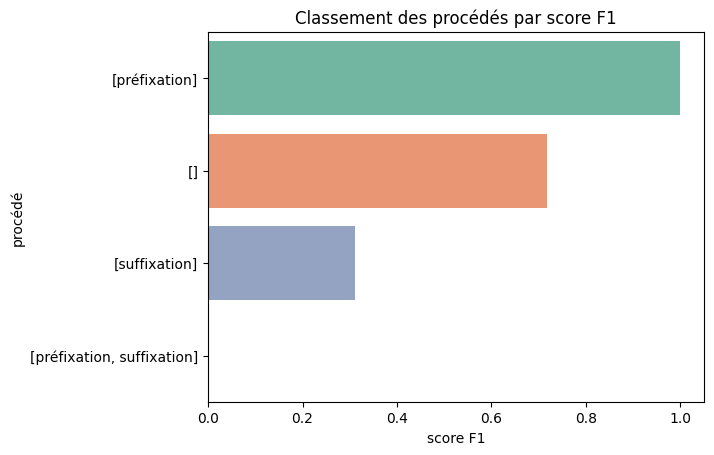

In [ ]:
# lecture du fichier contenant les réponses du LLM pour la question du procédé morphologique
proc = pd.read_csv("./proc_annotation.csv", usecols = ["source", "lemma", "proc"])
proc = proc[proc["source"] != "NS"].reset_index().drop(columns=["index"]) # nous n'analyserons que les réponses des données qui ont été shuffled (S)

# enlever les '
proc["proc"] = proc["proc"].str.replace("'", "", regex=False)

# lower toutes les réponses pour avoir suffixation au lieu de Suffixation
proc["proc"] = proc['proc'].str.lower()

# dire que préfixe = préfixation, suffixe = suffixation et préfixe, suffixe = préfixation, suffixation
proc["proc"] = proc["proc"].str.replace("préfixe", "préfixation", regex=False)\
                           .str.replace("suffixe", "suffixation", regex=False)\
                           .str.replace("préfixe, suffixe", "préfixation, suffixation", regex=False)

# tout ce qui n'est pas mes 4 classes possibles = AUTRE
classes = ["[préfixation]", "[suffixation]", "[préfixation, suffixation]", "[]"]
proc.loc[~proc["proc"].isin(classes), "proc"] = "AUTRE"

# réorientation du tableau pour faciliter le traitement
proc = proc.pivot(index="lemma", columns="source", values="proc").reset_index()

# construction d'une matrice de confusion vide pour calculer TP, TN, FP et FN
ar = np.zeros((5, 4), dtype=int)
df = pd.DataFrame(ar, index = ["[préfixation]", "[suffixation]", "[préfixation, suffixation]", "[]", "AUTRE"], columns = classes)

# remplissage de la matrice
for idx, row in proc.iterrows() :
    df.loc[row["S"], row["G"]] += 1

# calcul des indicateurs de qualité TP, FP, FN, TN
indics = quality_indic(df)

# calcul des scores precision, recall et F1 pour toutes les classes
F1_scores_dict = {}

for k in indics.keys() :
  TP = indics[k][0]
  FP = indics[k][1]
  FN = indics[k][2]
  TN = indics[k][3]

  prec = precision(TP, FP)
  rec = recall(TP, FN)
  F1 = F1_score(prec, rec)
  F1_scores_dict[k] = F1

  print(f"Precision de la classe {k} : {prec}")
  print(f"Recall de la classe {k} : {rec}")
  print(f"F1 score de la classe {k} : {F1}")
  print("\n--------------------------------------------\n")

# classement des procédés par score F1
df_F1 = pd.DataFrame.from_dict(
    F1_scores_dict,
    orient='index',
    columns=['score F1']
)

data = df_F1.reset_index()
data.columns = ["procédé", "score F1"]
data = data.sort_values(by="score F1", ascending=False)

sns.barplot(
    data=data,
    x="score F1",
    y="procédé",
    hue="procédé",
    palette="Set2",
    legend=False
)

plt.title("Classement des procédés par score F1")
plt.show()

Ce que nous pouvons dire des performances du modèle en voyant les scores :
- il ne s'est jamais trompé pour la classe préfixation
- quand il dit que c'est une suffixation, nous pouvons le croire à 90%, par contre, il ne sait pas systématiquement les identifier, il en oublie beaucoup
- il n'a jamais réussi à identifier un cas de préfixation, suffixation
- quand il dit que c'est [], il a juste une fois sur deux, par contre ! 94% du temps, quand il fallait répondre [], il a répondu correctement => en fait il a tendance à répondre [] plus souvent

##Accuracy

In [ ]:
# calcul de l'accuracy
accuracy_proc = 0

for k in indics.keys() :
  accuracy_proc += indics[k][0]

print(f"Nombre d'entrées avec une réponse correcte : {accuracy_proc}/{len(proc)}")
accuracy_proc = accuracy_proc / len(proc)

print(f"Accuracy pour la question du procédé morphologique : {accuracy_proc}")

Nombre d'entrées avec une réponse correcte : 57/100
Accuracy pour la question du procédé morphologique : 0.57


🟢**métrique en accord avec mes observations**🟢

A l'évaluation qualitative j'avais aussi trouvé un total de 57 entrées correctement identifiées.

Precision de la classe [préfixation] : 1.0
Recall de la classe [préfixation] : 1.0
F1 score de la classe [préfixation] : 1.0

--------------------------------------------

Precision de la classe [suffixation] : 1.0
Recall de la classe [suffixation] : 0.1875
F1 score de la classe [suffixation] : 0.3157894736842105

--------------------------------------------

Precision de la classe [préfixation, suffixation] : 0
Recall de la classe [préfixation, suffixation] : 0.0
F1 score de la classe [préfixation, suffixation] : 0

--------------------------------------------

Precision de la classe [] : 0.0
Recall de la classe [] : nan
F1 score de la classe [] : nan

--------------------------------------------



/tmp/ipykernel_554/277421578.py:23: RuntimeWarning: invalid value encountered in scalar divide
  recall = TP / (TP + FN)


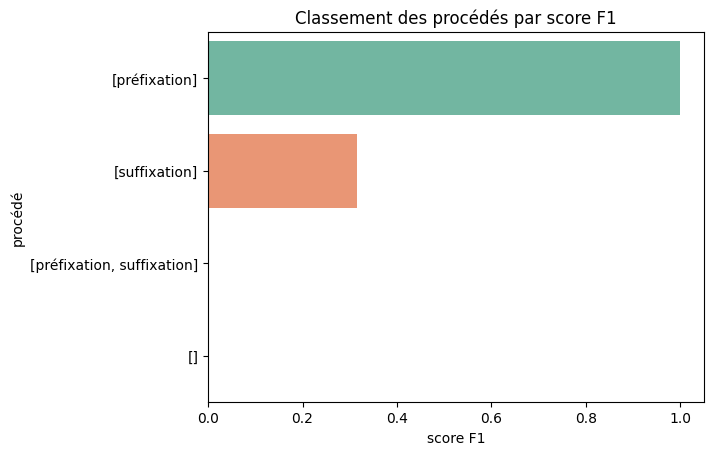

In [ ]:
# ajout du label pour pouvoir analyser uniquement les supplétifs
gold_dataset = pd.read_csv("./gold_dataset.csv", usecols=["lemma", "label"])
gold_dataset = gold_dataset.sort_values(by=["lemma"], ascending=True).reset_index().drop(columns=["index"])
proc_sup = pd.merge(proc, gold_dataset, on=["lemma"])
proc_sup = proc_sup[proc_sup["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# construction d'une matrice de confusion vide pour calculer TP, TN, FP et FN
ar = np.zeros((5, 4), dtype=int)
df = pd.DataFrame(ar, index = ["[préfixation]", "[suffixation]", "[préfixation, suffixation]", "[]", "AUTRE"], columns = classes)

# remplissage de la matrice
for idx, row in proc_sup.iterrows() :
    df.loc[row["S"], row["G"]] += 1

# calcul des indicateurs de qualité TP, FP, FN, TN
indics = quality_indic(df)

# calcul des scores precision, recall et F1 pour toutes les classes
F1_scores_dict = {}

for k in indics.keys() :
  TP = indics[k][0]
  FP = indics[k][1]
  FN = indics[k][2]
  TN = indics[k][3]

  prec = precision(TP, FP)
  rec = recall(TP, FN)
  F1 = F1_score(prec, rec)
  F1_scores_dict[k] = F1

  print(f"Precision de la classe {k} : {prec}")
  print(f"Recall de la classe {k} : {rec}")
  print(f"F1 score de la classe {k} : {F1}")
  print("\n--------------------------------------------\n")

# classement des procédés par score F1
df_F1 = pd.DataFrame.from_dict(
    F1_scores_dict,
    orient='index',
    columns=['score F1']
)

data = df_F1.reset_index()
data.columns = ["procédé", "score F1"]
data = data.sort_values(by="score F1", ascending=False)

sns.barplot(
    data=data,
    x="score F1",
    y="procédé",
    hue="procédé",
    palette="Set2",
    legend=False
)

plt.title("Classement des procédés par score F1")
plt.show()

In [ ]:
# calcul de l'accuracy
accuracy_proc_sup = 0

for k in indics.keys() :
  accuracy_proc_sup += indics[k][0]

print(f"Nombre d'entrées pour lesquelles le LLM a répondu parfaitement : {accuracy_proc_sup}/{len(proc_sup)}")
accuracy_proc_sup = accuracy_proc_sup / len(proc_sup)
print(f"Accuracy pour la question du procédé : {accuracy_proc_sup}")

Nombre d'entrées pour lesquelles le LLM a répondu parfaitement : 10/50
Accuracy pour la question du procédé : 0.2


# Q1 - proc V2


In [ ]:
def is_in_context(llm_answers, context) :
  context = context.lower()
  for s in llm_answers :
    s = s.lower()

    # recherche info explicite
    if s.endswith("ation") :
      t = s[:-5] + "e" # on enlève le ation et on ajoute e (ex : suffixation -> suffixe)
    elif s.endswith("e") :
      t = s[:-1] + "ation" # suffixe -> suffixation
    else :
      t = s
    explicit = (s in context) or (t in context)

    # recherche info implicite
    if s == "préfixe" or t == "préfixe" :
      regexp = r"\w+-(?=($|\s|\.|,))"
    elif s == "suffixe" or t == "suffixe" :
      regexp = r"(?<=\s)-\w+"
    else :
      regexp = None
    implicit = (regexp is not None) and ( re.search(regexp, context) is not None )

    if not explicit and not implicit :
      return False

  return True

def proc_score(gold_answers, llm_answers, context) :
  score = 0
  if is_in_context(llm_answers, context) and not is_in_context(gold_answers, context) :
    score = 0.5
  llm_answers = [ s.lower()[:-1] + "ation" if s.endswith("e") else s.lower() for s in llm_answers ] # Préfixe -> préfixation
  llm_answers = sorted(llm_answers)
  if len(llm_answers) == len(gold_answers) and all([ x == y for (x,y) in zip(llm_answers, gold_answers) ]) :
    score = 1
  return score

In [ ]:
proc = pd.read_csv("./proc_annotation.csv", usecols = ["source", "lemma", "proc", "score"]).rename(columns={"proc" : "llm_proc"})
proc = proc[ proc["source"] == "S"] # on ne garde que les réponses de shuffled
gold_dataset = pd.read_csv("./gold_dataset.csv", usecols=["lemma", "etym", "proc", "label"])
gold_dataset = gold_dataset.sort_values(by=["lemma"], ascending=True).reset_index().drop(columns=["index"])
gold_dataset_annotated = pd.merge(proc, gold_dataset, on=["lemma"])

gold_dataset_annotated["metric_score"] = [ proc_score( eval(row["proc"]), eval(row["llm_proc"]), str(row["etym"]) ) for idx, row in gold_dataset_annotated.iterrows() ]
gold_dataset_annotated

,source,lemma,llm_proc,score,etym,proc,label,metric_score
0,S,actinique,['Composé'],0.0,"['Composé du grec ancien ἀκτίς, ἀκτῖνος, aktis...",['suffixation'],supplétion régulière,0.0
1,S,adipeux,['Suffixation'],1.0,"['Dérivé savant du latin adeps, adipis (« grai...",['suffixation'],supplétion régulière,1.0
2,S,an,[],1.0,"['Du latin annus (« cercle, an, âge, récolte d...",[],non dérivé,1.0
3,S,antifébrile,['Composé'],0.5,"['Composé de anti-, fébrile et fièvre.']","['préfixation', 'suffixation']",supplétion régulière,0.5
4,S,arbre,[],1.0,"['Du moyen français arbre, de l’ancien françai...",[],non dérivé,1.0
...,...,...,...,...,...,...,...,...
95,S,verbe,[],1.0,"[""Du latin verbum (« parole »), de l'indo-euro...",[],non dérivé,1.0
96,S,viaire,['Suffixation'],1.0,"['et (nom commun 1) Du latin via, avec le suff...",['suffixation'],supplétion rare,1.0
97,S,visible,[],0.5,['Du latin visibilis.'],['suffixation'],supplétion régulière,0.5
98,S,école,[],1.0,"['De l’ancien français escole, d’un latin tard...",[],non dérivé,1.0


In [ ]:
compute_tests( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

{'MSE': 0.07071067811865475,
 'pearson': np.float64(0.9813206406006794),
 't-test-pvalue': np.float64(0.15833990565972564)}

In [ ]:
compute_kappa( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

np.float64(0.9648135116115412)

In [ ]:
gold_dataset_annotated["metric_score"].mean()

np.float64(0.715)

In [ ]:
gold_dataset_annotated_supp = gold_dataset_annotated[ gold_dataset_annotated["label"]!= "non dérivé"]
gold_dataset_annotated_supp["metric_score"].mean()

np.float64(0.49)

#Q2 - aff

In [ ]:
# lecture du fichier contenant les réponses du LLM pour la question de l'affixe
aff = pd.read_csv("./aff_annotation.csv", usecols = ["source", "lemma", "aff"])
aff = aff[aff["source"] != "NS"].reset_index().drop(columns=["index"]) # nous n'analyserons que les réponses des données qui ont été shuffled (S)

# réorientation du tableau pour faciliter le traitement
aff = aff.pivot(index="lemma", columns="source", values="aff").reset_index()

# ajout du label pour pouvoir analyser uniquement les supplétifs
gold_dataset = pd.read_csv("./gold_dataset.csv", usecols=["lemma", "label"])
gold_dataset = gold_dataset.sort_values(by=["lemma"], ascending=True).reset_index().drop(columns=["index"])
aff = pd.merge(aff, gold_dataset, on=["lemma"])

##Levenshtein distance et ratio

In [ ]:
# calcul de la Levenshtein distance et du Levenshtein ratio
# utilité de Levenshtein ratio => vérifier si les petites distances comme 3 et 4 sont dues à la longueur des réponses qui était petite de base, ou si vraiment le LLM n'était pas loin de trouver la bonne réponse
# nous pouvons constater que ['-ier'] et ['eau'] n'ont rien à voir et pourtant la distance est basse, 4, alors que pour ['anti-', '-ile'] et ['anti-', 'fébrile'], la distance est aussi de 4 mais là on voit clairement un lien de similarité entre les deux
for idx, row in aff.iterrows() :
  input1 = row["G"]
  input2 = row["S"]
  dist_calc = Levenshtein.distance(input1, input2)
  check_sim = Levenshtein.ratio(input1, input2)
  aff.loc[idx, "Levenshtein distance"] = dist_calc
  aff.loc[idx, "Levenshtein ratio"] = check_sim

##Accuracy : est-ce que le LLM a trouvé le bon affixe ?

In [ ]:
aff = aff[aff["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# seule la distance de Levenshtein est prise en compte, et si elle n'est pas égale à 0, la réponse est fausse
strict_accuracy_aff = 0

for dist in aff["Levenshtein distance"] :
  if dist == 0 :
    strict_accuracy_aff += 1

print(f"Nombre d'entrées pour lesquelles le LLM a parfaitement répondu (distance=0) : {strict_accuracy_aff}/{len(aff)}")
strict_accuracy_aff = strict_accuracy_aff / len(aff)
print(f"Accuracy stricte pour la question de l'affixe : {strict_accuracy_aff}")

print(f"\n--------------------------------------------------------------------------------\n")

# cette fois, la similitude entre la référence et la réponse du LLM est prise en compte, il faut que la distance soit basse mais pas forcément égale à 0
# j'ai décidé que 0.8 était un bon seuil pour le Levenshtein ratio
soft_accuracy_aff = 0

for ratio in aff["Levenshtein ratio"] :
  if ratio > 0.8 :
    soft_accuracy_aff += 1

print(f"Nombre d'entrées pour lesquelles le LLM a répondu quelque chose de plausible (ratio>0.8) : {soft_accuracy_aff}/{len(aff)}")
soft_accuracy_aff = soft_accuracy_aff / len(aff)
print(f"Accuracy plus souple pour la question de l'affixe : {soft_accuracy_aff}")

Nombre d'entrées pour lesquelles le LLM a parfaitement répondu (distance=0) : 10/50
Accuracy stricte pour la question de l'affixe : 0.2

--------------------------------------------------------------------------------

Nombre d'entrées pour lesquelles le LLM a répondu quelque chose de plausible (ratio>0.8) : 12/50
Accuracy plus souple pour la question de l'affixe : 0.24


🟢**métrique en accord avec mes observations**🟢

J'avais également trouvé 10 entrées supplétives bien identifiées par le LLM, ce qui faisait un score moyen de 0.2 également.

##Cohérence : est-ce que le LLM a trouvé un affixe possible ?

In [ ]:
aff["G"] = aff["G"].str.replace("[", "", regex=False)\
                           .str.replace("]", "", regex=False)\
                           .str.replace("'", "", regex=False)

aff["S"] = aff["S"].str.replace("[", "", regex=False)\
                           .str.replace("]", "", regex=False)\
                           .str.replace("'", "", regex=False)

consistency = 0

for idx, row in aff.iterrows() :
  if len(row["G"].split("-")[0]) == 0 : # c'est un suffixe
    lemma = row["lemma"]
    suff = row["S"].split("-")[-1]
    if lemma.endswith(suff) and len(lemma) > len(suff) : # suffixe strict (antifébrile)
      consistency += 1
  elif len(row["G"].split("-")[-1]) == 0 : # c'est un préfixe
    lemma = row["lemma"]
    pref = row["S"].split("-")[0]
    if lemma.startswith(pref) and len(lemma) > len(pref) :
      consistency += 1
  else : # c'est un préfixe + un suffixe
    lemma = row["lemma"]
    pref = row["S"].split("-")[0]
    suff = row["S"].split("-")[-1]
    if (lemma.startswith(pref) and len(lemma) > len(pref)) and (lemma.endswith(suff) and len(lemma) > len(suff)) :
      consistency += 1
    elif (lemma.startswith(pref) and len(lemma) > len(pref)) or (lemma.endswith(suff) and len(lemma) > len(suff)):
      consistency += 0.5

consistent_entries = consistency
consistency = consistency / len(aff)

print(f"Nombre d'entrées pour lesquelles le LLM a produit un affixe plausible : {consistent_entries}/{len(aff)}")
print(f"Cohérence globale du LLM : {consistency}")

Nombre d'entrées pour lesquelles le LLM a produit un affixe plausible : 27.5/50
Cohérence globale du LLM : 0.55


# Q2 - aff V2

In [ ]:
def aff_score( gold_answers, llm_answers, context) :
  gold_answers = gold_answers.replace("[", "").replace("]", "").replace("'","").replace("-", "")
  llm_answers = llm_answers.replace("[", "").replace("]", "").replace("'","").replace("-", "")
  m = max( len(gold_answers), len(llm_answers) )
  if m == 0 :
    return 1
  if not all([x.strip() in context for x in gold_answers.split(",")]) and len(llm_answers) == 0 :
    return 0.5
  ratio = 1 - (Levenshtein.distance( gold_answers, llm_answers ) / m)
  if ratio <= 1/3 :
    ratio = 0
  elif ratio >= 2/3 :
    ratio = 1
  else :
    ratio = 0.5
  return ratio

In [ ]:
aff = pd.read_csv("./aff_annotation.csv", usecols = ["source", "lemma", "aff", "score"]).rename(columns={"aff" : "llm_aff"})
aff = aff[ aff["source"] == "S"] # on ne garde que les réponses de shuffled
gold_dataset = pd.read_csv("./gold_dataset.csv", usecols=["lemma", "etym", "aff", "label"])
gold_dataset = gold_dataset.sort_values(by=["lemma"], ascending=True).reset_index().drop(columns=["index"])
gold_dataset_annotated = pd.merge(aff, gold_dataset, on=["lemma"])

gold_dataset_annotated["metric_score"] = [ aff_score( str(row["aff"]), str(row["llm_aff"]), row["etym"] ) for idx, row in gold_dataset_annotated.iterrows() ]
gold_dataset_annotated

,source,lemma,llm_aff,score,etym,aff,label,metric_score
0,S,actinique,['-ique'],1.0,"['Composé du grec ancien ἀκτίς, ἀκτῖνος, aktis...",['-ique'],supplétion régulière,1.0
1,S,adipeux,['-eux'],1.0,"['Dérivé savant du latin adeps, adipis (« grai...",['-eux'],supplétion régulière,1.0
2,S,an,['annus'],0.0,"['Du latin annus (« cercle, an, âge, récolte d...",[],non dérivé,0.0
3,S,antifébrile,"['anti-', 'fébrile']",0.5,"['Composé de anti-, fébrile et fièvre.']","['anti-', '-ile']",supplétion régulière,1.0
4,S,arbre,['ar-'],0.0,"['Du moyen français arbre, de l’ancien françai...",[],non dérivé,0.0
...,...,...,...,...,...,...,...,...
95,S,verbe,['*werdʰh₁o-'],0.0,"[""Du latin verbum (« parole »), de l'indo-euro...",[],non dérivé,0.0
96,S,viaire,['et'],0.0,"['et (nom commun 1) Du latin via, avec le suff...",['-aire'],supplétion rare,0.0
97,S,visible,['vis-'],0.0,['Du latin visibilis.'],['-ible'],supplétion régulière,0.0
98,S,école,['*'],0.0,"['De l’ancien français escole, d’un latin tard...",[],non dérivé,0.0


{'MSE': 0.8617131145468451,
 'pearson': np.float64(0.9690826417459897),
 't-test-pvalue': np.float64(4.944358786136765e-05)}

In [ ]:
compute_tests( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

{'MSE': 0.1,
 'pearson': np.float64(0.9578065496994619),
 't-test-pvalue': np.float64(0.04493472521263044)}



{'MSE': 1.0,
 'pearson': np.float64(0.9578065496994619),
 't-test-pvalue': np.float64(0.04493472521263044)}

In [ ]:
compute_kappa( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

np.float64(0.8372660699755898)

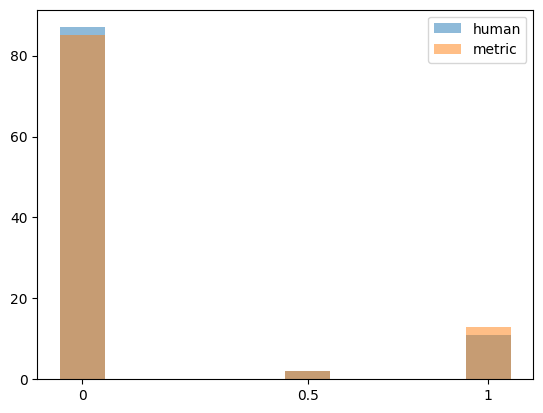

In [ ]:
import matplotlib.pyplot as plt

plt.hist(gold_dataset_annotated["score"], alpha=0.5, label="human", align="mid")
plt.hist(gold_dataset_annotated["metric_score"], alpha=0.5, label="metric", align="mid")
plt.xticks(ticks=[0.05, 0.55, 0.95], labels=["0", "0.5", "1"])
plt.legend()

In [ ]:
gold_dataset_annotated["metric_score"].mean()

np.float64(0.14)

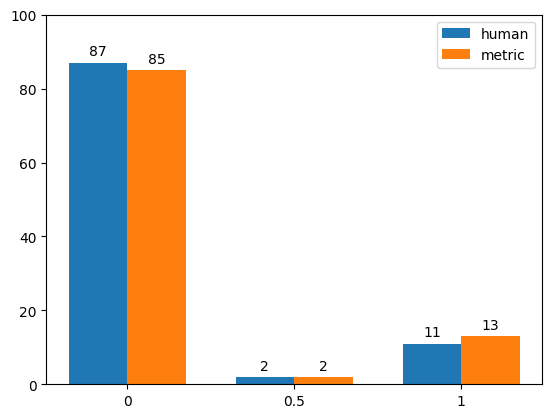

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Valeurs possibles des scores
score_values = [0, 0.5, 1]

# Compter les occurrences de chaque score pour les deux colonnes
human_counts = [ (gold_dataset_annotated["score"] == v).sum() for v in score_values ]
metric_counts = [ (gold_dataset_annotated["metric_score"] == v).sum() for v in score_values ]

x = np.arange(len(score_values))  # positions des groupes
width = 0.35  # largeur des barres

fig, ax = plt.subplots()
bars_human = ax.bar(x - width/2, human_counts, width, label="human")
bars_metric = ax.bar(x + width/2, metric_counts, width, label="metric")

ax.set_xticks(x)
ax.set_xticklabels(["0", "0.5", "1"])
ax.set_ylim(0, 100)
ax.legend()

# Afficher le nombre exact au-dessus de chaque barre
ax.bar_label(bars_human, padding=3)
ax.bar_label(bars_metric, padding=3)

plt.show()

In [ ]:
gold_dataset_annotated_supp = gold_dataset_annotated[ gold_dataset_annotated["label"]!= "non dérivé"]
gold_dataset_annotated_supp["metric_score"].mean()

np.float64(0.26)

#Q3 - rad

In [ ]:
# lecture du fichier contenant les réponses du LLM pour la question du radical
rad = pd.read_csv("./rad_annotation.csv", usecols = ["source", "lemma", "rad"])
rad = rad[rad["source"] != "NS"].reset_index().drop(columns=["index"]) # nous n'analyserons que les réponses des données qui ont été shuffled (S)

# réorientation du tableau pour faciliter le traitement
rad = rad.pivot(index="lemma", columns="source", values="rad").reset_index()

# ajout du label pour pouvoir analyser uniquement les supplétifs
rad = pd.merge(rad, gold_dataset, on=["lemma"])

# remplacement des NaN par rien pour pouvoir calculer les distance et ratio de Levenshtein
rad = rad.fillna("")

##Levenshtein distance et ratio

In [ ]:
# calcul de la Levenshtein distance et du Levenshtein ratio
# utilité de Levenshtein ratio => pouvoir prendre en compte les nombreuses entrées qui n'ont pas une distance égale à 1 à cause d'un oubli de tiret (lact et non lact-) ou à cause d'un autre caractère
for idx, row in rad.iterrows() :
  input1 = row["G"]
  input2 = row["S"]
  dist_calc = Levenshtein.distance(input1, input2)
  check_sim = Levenshtein.ratio(input1, input2)
  rad.loc[idx, "Levenshtein distance"] = dist_calc
  rad.loc[idx, "Levenshtein ratio"] = check_sim

##Accuracy : est-ce que le LLM a trouvé le bon radical ?

In [ ]:
rad = rad[rad["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# seule la distance de Levenshtein est prise en compte, et si elle n'est pas égale à 1, la réponse est fausse
strict_accuracy_rad = 0

for dist in rad["Levenshtein distance"] :
  if dist == 0 :
    strict_accuracy_rad += 1

print(f"Nombre d'entrées pour lesquelles le LLM a parfaitement répondu (distance=0) : {strict_accuracy_rad}/{len(rad)}")
strict_accuracy_rad = strict_accuracy_rad / len(rad)
print(f"Accuracy stricte pour la question du radical : {strict_accuracy_rad}")

print(f"\n--------------------------------------------------------------------------------\n")

# cette fois, la similitude entre la référence et la réponse du LLM est prise en compte, il faut que la distance soit basse mais pas forcément égale à 0
# j'ai décidé que 0.8 était un bon seuil pour le Levenshtein ratio
soft_accuracy_rad = 0

for ratio in rad["Levenshtein ratio"] :
  if ratio > 0.8 :
    soft_accuracy_rad += 1

print(f"Nombre d'entrées pour lesquelles le LLM a répondu quelque chose de plausible (ratio>0.8) : {soft_accuracy_rad}/{len(rad)}")
soft_accuracy_rad = soft_accuracy_rad / len(rad)
print(f"Accuracy plus souple pour la question du radical : {soft_accuracy_rad}")

KeyError: 'label'

🟡**métrique presque en accord avec mes observations**🟡

A l'evaluation qualitative j'avais trouvé 0.4 et là je trouve, au plus, 0.32. Cela s'explique parce que j'avais mis des scores 0.5 lorsque le modèle ne pouvait pas savoir et qu'il n'avait rien répondu, alors qu'ici, tout cequi correspond à un score 0.5 est en fait 0. Cela fait que le score moyen final était plus élevé.

##Cohérence : est-ce que le LLM a trouvé un radical possible ?

In [ ]:
# enlever les tirets pour pouvoir utiliser une regex avec comme pattern le radical
rad["S"] = rad["S"].str.replace("-", "", regex=False)

consistency_rad = 0

for idx, row in rad.iterrows() :
  if len(row["S"]) < len(row["lemma"]) : # en sachant qu'une réponse NaN est considérée comme juste aussi => parce que, dans ce cas, le LLM veut dire que l'entrée est non dérivée pour lui et ça reste possible, plus possible que d'inventer n'importe quoi
    result = re.search(row["S"], row["lemma"])
    if result != None :
      consistency_rad += 1

consistent_entries_rad = consistency_rad
consistency_rad = consistency_rad / len(rad)
print(f"Nombre d'entrées pour lesquelles le LLM a produit un radical plausible : {consistent_entries_rad}/{len(rad)}")
print(f"Cohérence globale du LLM : {consistency_rad}")

Le modèle se débrouille mieux qu'avec les affixes (cohérence supérieure) => c'est ce que j'avais pu constater lors de mes annotations : il invente beaucoup moins même si il trouve le même nombre d'entrées correctes (de manière stricte) pour les affixes et pour le radical.

# Q3 - rad V2

In [ ]:
dic = pyphen.Pyphen(lang="fr")

def is_split_following_syllables(rad, word) :
  syllables = dic.inserted(word).split("-")
  for i, syllable in enumerate(syllables) :
    if rad.startswith(syllable) :
      for next_syllable in syllables[i+1:] :
        syllable += next_syllable
        if syllable == rad :
          return True
  return False

In [ ]:
def rad_score( gold_answer, llm_answer, lemma ) :
  gold_answer = gold_answer.replace("-", "")
  llm_answer = llm_answer.replace("-", "")
  if gold_answer == llm_answer :
    return 1
  gold_answer = unidecode.unidecode(gold_answer)
  llm_answer = unidecode.unidecode(llm_answer)
  if llm_answer == lemma :
    return 0
  elif gold_answer == llm_answer or is_split_following_syllables(llm_answer, lemma) :
    return 0.5
  return 0

In [ ]:
rad = pd.read_csv("./rad_annotation.csv", usecols = ["source", "lemma", "rad", "score"]).rename(columns={"rad" : "llm_rad"})
rad = rad[ rad["source"] == "S"] # on ne garde que les réponses de shuffled
gold_dataset = pd.read_csv("./gold_dataset.csv", usecols=["lemma", "etym", "rad", "label"])
gold_dataset = gold_dataset.sort_values(by=["lemma"], ascending=True).reset_index().drop(columns=["index"])
gold_dataset_annotated = pd.merge(rad, gold_dataset, on=["lemma"])

gold_dataset_annotated["metric_score"] = [ rad_score( str(row["rad"]), str(row["llm_rad"]), row["lemma"] ) for idx, row in gold_dataset_annotated.iterrows() ]
gold_dataset_annotated

,source,lemma,llm_rad,score,etym,rad,label,metric_score
0,S,actinique,actis,0.0,"['Composé du grec ancien ἀκτίς, ἀκτῖνος, aktis...",actin-,supplétion régulière,0.0
1,S,adipeux,adip-,1.0,"['Dérivé savant du latin adeps, adipis (« grai...",adip-,supplétion régulière,1.0
2,S,an,NaN,1.0,"['Du latin annus (« cercle, an, âge, récolte d...",NaN,non dérivé,1.0
3,S,antifébrile,antifébrile,0.0,"['Composé de anti-, fébrile et fièvre.']",-fébr-,supplétion régulière,0.0
4,S,arbre,ar,0.0,"['Du moyen français arbre, de l’ancien françai...",NaN,non dérivé,0.0
...,...,...,...,...,...,...,...,...
95,S,verbe,NaN,1.0,"[""Du latin verbum (« parole »), de l'indo-euro...",NaN,non dérivé,1.0
96,S,viaire,via,0.0,"['et (nom commun 1) Du latin via, avec le suff...",vi-,supplétion rare,0.0
97,S,visible,visible,0.0,['Du latin visibilis.'],vis-,supplétion régulière,0.0
98,S,école,école,0.0,"['De l’ancien français escole, d’un latin tard...",NaN,non dérivé,0.0


In [ ]:
compute_tests( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

{'MSE': 0.08660254037844387,
 'pearson': np.float64(0.9783255033805597),
 't-test-pvalue': np.float64(0.5663155080996354)}

{'MSE': 0.8660254037844386,
 'pearson': np.float64(0.9783255033805597),
 't-test-pvalue': np.float64(0.5663155080996354)}

In [ ]:
compute_kappa( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

np.float64(0.9267220322423058)

In [ ]:
gold_dataset_annotated["metric_score"].mean()

np.float64(0.24)

In [ ]:
gold_dataset_annotated_supp = gold_dataset_annotated[ gold_dataset_annotated["label"]!= "non dérivé"]
gold_dataset_annotated_supp["metric_score"].mean()

np.float64(0.32)

#Q4 - etym mean

In [ ]:
# lecture du fichier contenant les réponses du LLM pour la question de l'étymon et du sens
etym_mean = pd.read_csv("./etym_mean_annotation.csv", usecols = ["source", "lemma", "etym_mean"])
etym_mean = etym_mean[etym_mean["source"] != "NS"].reset_index().drop(columns=["index"])

# quand le LLM ne retourne une liste vide, remplacer par une liste de couple étymon-sens vide afin de pouvoir comparer plus facilement avec la référence
etym_mean["etym_mean"] = etym_mean["etym_mean"].str.replace("[]", "[('', '')]", regex=False)

# réorientation du tableau pour faciliter le traitement
etym_mean = etym_mean.pivot(index="lemma", columns="source", values="etym_mean").reset_index()

# ajout du label pour pouvoir analyser uniquement les supplétifs
etym_mean = pd.merge(etym_mean, gold_dataset, on=["lemma"])
etym_mean = etym_mean[etym_mean["label"] != "non dérivé"].reset_index().drop(columns=["index"])

##Precision, Recall, F1 score

In [ ]:
# création d'une fonction qui calculera la similarité entre le sens du Gold et le sens du LLM pour un couple donné
# référence https://huggingface.co/antoinelouis/biencoder-distilcamembert-mmarcoFR

encoder = SentenceTransformer('antoinelouis/biencoder-distilcamembert-mmarcoFR')

def compute_cosine_similarity(text1, text2) :
  if text1 == text2 :
    return 1
  elif len(text1) == 0 or len(text2) == 0 :
    return 0
  else :
    embed1 = encoder.encode([text1], normalize_embeddings=True)[0, :]
    embed2 = encoder.encode([text2], normalize_embeddings=True)[0, :]
    cosine_sim = np.dot(embed1 , embed2) / (np.linalg.norm(embed1) * np.linalg.norm(embed2))
    return cosine_sim

# La fonction cosine_sim passe les deux mots dans un encodeur pour les transformer
# en vecteur et compare leur représentation vectorielle avec la similarité cosinus

In [ ]:
compute_cosine_similarity("viande","chair")

In [ ]:
# création d'un mapping qui associe les bons couples ensemble
# par exemple, quand il y a plusieurs couples dans le Gold et plusieurs couples dans le LLM
# ce n'est pas dit que le couple 1 dans le Gold corresponde au couple 1 dans le LLM
# donc on va mapper les couples qui sont censés être ensemble à l'aide du Levenshtein ratio (pour les étymons, car nous attendons un étymon en particulier avec plus ou moins de variation orthographique)
# et de la similarité cosinus (pour les sens, car cette fois, si le LLM répond un synonyme comme potence à la place de gibet, cela est considéré comme juste)

mappings = [ [] for i in range(len(etym_mean)) ]

for idx, row in etym_mean.iterrows() :
  similarities = {}
  G = eval(row["G"])
  S = eval(row["S"])
  for elemg in range(len(G)) :
    for elems in range(len(S)) :
      input1 = G[elemg]
      input2 = S[elems]
      check_sim = Levenshtein.ratio(input1[0], input2[0])
      cosine_sim = compute_cosine_similarity(input1[1], input2[1])
      similarities[(elemg, elems)] = check_sim * cosine_sim

  similarities_list = list(similarities.items())
  while len(similarities_list) > 0 :
    closest_pair = sorted(similarities_list, key=lambda item: item[1])[-1][0] # paire avec la plus grande similarité
    mappings[idx].append(closest_pair)
    similarities_list = [ (k,v) for k,v in similarities_list if k[0] != closest_pair[0] and k[1] != closest_pair[1] ]

# calcul des scores
# l'étymon est calculé avec une distance de Lenvenshtein, le sens est calculé avec similarité cosinus
# ensuite je fais la moyenne des deux pour avoir un seul score pour un couple
# s'il y a plusieurs couples, et bien je fais la somme de tous les couples puis je divise par le nombre de réponses attendues (recall) ou par la nombre de réponses données (precision)

for idx, row in etym_mean.iterrows() :
  G = eval(row["G"])
  S = eval(row["S"])
  sum = 0
  for couple in mappings[idx] :
    input1 = G[couple[0]]
    input2 = S[couple[1]]
    dist_calc = Levenshtein.distance(input1[0], input2[0])

    if len(input1[0]) >= len(input2[0]) :
      max_len = len(input1[0])
    else :
      max_len = len(input2[0])

    if max_len == 0 :
      etym_score = 1
    else :
      etym_score = 1 - (dist_calc/max_len)

    mean_score = compute_cosine_similarity(input1[1], input2[1])
    couple_score = (etym_score + mean_score)/2
    sum += couple_score

  prec = sum/len(S)
  rec = sum/len(G)
  f1 = F1_score(prec, rec)
  etym_mean.loc[idx, "precision"] = prec
  etym_mean.loc[idx, "recall"] = rec
  etym_mean.loc[idx, "F1"] = f1

# calcul d'un score moyen
mean_score_etym_mean = etym_mean["F1"].mean()
print(f"F1 score moyen pour la question des couples étymon-sens : {mean_score_etym_mean}")

🟡**métrique presque en accord avec mes observations**🟡

A l'evaluation qualitative j'avais trouvé 0.33 et là je trouve un peu plus => 0.41.

# Q4 - etym_mean V2

In [ ]:
# création d'une fonction qui calculera la similarité entre le sens du Gold et le sens du LLM pour un couple donné
# référence https://huggingface.co/antoinelouis/biencoder-distilcamembert-mmarcoFR

encoder = SentenceTransformer('antoinelouis/biencoder-distilcamembert-mmarcoFR')

def compute_cosine_similarity(text1, text2) :
  if text1 == text2 :
    return 1
  elif len(text1) == 0 or len(text2) == 0 :
    return 0
  else :
    embed1 = encoder.encode([text1], normalize_embeddings=True)[0, :]
    embed2 = encoder.encode([text2], normalize_embeddings=True)[0, :]
    cosine_sim = np.dot(embed1 , embed2) / (np.linalg.norm(embed1) * np.linalg.norm(embed2))
    return cosine_sim

# La fonction cosine_sim passe les deux mots dans un encodeur pour les transformer
# en vecteur et compare leur représentation vectorielle avec la similarité cosinus

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.48k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B /  811kB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/353 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def etym_mean_similar(g, l, threshold=0.6) :
  # vérifier l'étymon
    g_etyms = g[0].split(",")
    l_etym = l[0]
    etym_correct = any([ g_etym.strip() == l_etym for g_etym in g_etyms ])

    # vérifier le sens
    g_mean = g[1]
    l_mean = l[1]
    mean_correct = compute_cosine_similarity(g_mean, l_mean) > threshold

    return etym_correct and mean_correct

def etym_mean_perfect_match(gold_answer, llm_answer) :
  if len(gold_answer) != len(llm_answer) :
    return False
  gold_answer = sorted(gold_answer, key = lambda x : x[0])
  llm_answer = sorted(llm_answer, key = lambda x : x[0])
  return all( [ etym_mean_similar(g,l) for g, l in zip(gold_answer, llm_answer) ] )

def etym_mean_half_match(gold_answer, llm_answer, context) :
  partially_correct = any( [ etym_mean_similar(g,l) for g in gold_answer for l in llm_answer ] ) # (3) et (5)
  cannot_be_found = len(llm_answer) == 0  and  all( [ etym.strip() not in context for g in gold_answer for etym in g[0].split(",")] ) # (4)
  return partially_correct or cannot_be_found

def etym_mean_score(gold_answer, llm_answer, context) :
  if etym_mean_perfect_match(gold_answer, llm_answer) :
    return 1
  elif etym_mean_half_match(gold_answer, llm_answer, context) :
    return 0.5
  return 0

In [ ]:
etymmean = pd.read_csv("./etym_mean_annotation.csv", usecols = ["source", "lemma", "etym_mean", "score"]).rename(columns={"etym_mean" : "llm_etym_mean"})
etymmean = etymmean[ etymmean["source"] == "S"] # on ne garde que les réponses de shuffled
gold_dataset = pd.read_csv("./gold_dataset.csv", usecols=["lemma", "etym", "etym_mean", "label"])
gold_dataset = gold_dataset.sort_values(by=["lemma"], ascending=True).reset_index().drop(columns=["index"])
gold_dataset_annotated = pd.merge(etymmean, gold_dataset, on=["lemma"])

gold_dataset_annotated["metric_score"] = [ etym_mean_score( eval(row["etym_mean"]), eval(row["llm_etym_mean"]), row["etym"] ) for idx, row in gold_dataset_annotated.iterrows() ]
gold_dataset_annotated

,source,lemma,llm_etym_mean,score,etym,etym_mean,label,metric_score
0,S,actinique,"[['grec ancien', 'rayon']]",0.0,"['Composé du grec ancien ἀκτίς, ἀκτῖνος, aktis...","[('aktis, aktinos', 'rayon')]",supplétion régulière,0.0
1,S,adipeux,"[['latin', 'graisse']]",0.0,"['Dérivé savant du latin adeps, adipis (« grai...","[('adeps, adipis', 'graisse')]",supplétion régulière,0.0
2,S,an,[],1.0,"['Du latin annus (« cercle, an, âge, récolte d...",[],non dérivé,1.0
3,S,antifébrile,"[['fébrile', 'fièvre'], ['fièvre', 'fever']]",0.0,"['Composé de anti-, fébrile et fièvre.']","[('febrilis', 'agité par la fièvre'), ('febris...",supplétion régulière,0.0
4,S,arbre,"[['arbor', 'arbre'], ['ab', 'haut'], ['or', 'o...",0.0,"['Du moyen français arbre, de l’ancien françai...",[],non dérivé,0.0
...,...,...,...,...,...,...,...,...
95,S,verbe,[],1.0,"[""Du latin verbum (« parole »), de l'indo-euro...",[],non dérivé,1.0
96,S,viaire,"[['et', 'nom commun 1'], ['via', 'voie publiqu...",0.5,"['et (nom commun 1) Du latin via, avec le suff...","[('via', 'voie')]",supplétion rare,0.5
97,S,visible,[],0.0,['Du latin visibilis.'],"[('visibilis', 'qui peut être vu'), ('visum', ...",supplétion régulière,0.0
98,S,école,"[['*escola', 'loisir studieux, leçon, lieu d’é...",0.0,"['De l’ancien français escole, d’un latin tard...",[],non dérivé,0.0


In [ ]:
compute_tests( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

{'MSE': 0.2,
 'pearson': np.float64(0.889400535697908),
 't-test-pvalue': np.float64(1.0)}

{'MSE': 2.0,
 'pearson': np.float64(0.889400535697908),
 't-test-pvalue': np.float64(1.0)}

In [ ]:
compute_kappa( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

np.float64(0.7730446927374302)

In [ ]:
gold_dataset_annotated["metric_score"].mean()

np.float64(0.335)

In [ ]:
gold_dataset_annotated_supp = gold_dataset_annotated[ gold_dataset_annotated["label"]!= "non dérivé"]
gold_dataset_annotated_supp["metric_score"].mean()

np.float64(0.25)

#Q5 - lang

##Vision stricte

La vision stricte correspond aux calculs de la precision, du recall, du score F1 et de l'accuracy quand la réponse du LLM n'est pas **exactement** la même que la réponse de la référence.

###Precision, Recall, F1 score

In [ ]:
# lecture du fichier contenant les réponses du LLM pour la question de la langue source
lang = pd.read_csv("./lang_annotation.csv", usecols = ["source", "lemma", "lang"])
lang = lang[lang["source"] != "NS"].reset_index().drop(columns=["index"])

# lower toutes les réponses pour avoir latin au lieu de Latin
lang["lang"] = lang["lang"].str.lower()

# tout ce qui n'est pas mes 5 classes possibles = AUTRE
classes = ["latin", "grec ancien", "bas latin", "ancien français"]
lang.loc[~lang["lang"].isin(classes), "lang"] = "AUTRE"

# réorientation du tableau pour faciliter le traitement
lang = lang.pivot(index="lemma", columns="source", values="lang").reset_index()

# ajout du label pour pouvoir analyser uniquement les supplétifs
lang = pd.merge(lang, gold_dataset, on=["lemma"])
lang = lang[lang["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# construction d'une matrice de confusion vide pour calculer TP, TN, FP et FN
ar = np.zeros((5, 4), dtype=int)
df = pd.DataFrame(ar, index = ["latin", "grec ancien", "bas latin", "ancien français", "AUTRE"], columns = classes)

# remplissage de la matrice
for idx, row in lang.iterrows() :
    df.loc[row["S"], row["G"]] += 1
print(df)
# calcul des indicateurs de qualité TP, FP, FN, TN
indics = quality_indic(df)

# calcul des scores precision, recall et F1 pour toutes les classes
F1_scores_dict = {}

for k in indics.keys() :
  TP = indics[k][0]
  FP = indics[k][1]
  FN = indics[k][2]
  TN = indics[k][3]

  prec = precision(TP, FP)
  rec = recall(TP, FN)
  F1 = F1_score(prec, rec)
  F1_scores_dict[k] = F1

  print(f"Precision de la classe {k} : {prec}")
  print(f"Recall de la classe {k} : {rec}")
  print(f"F1 score de la classe {k} : {F1}")
  print("\n--------------------------------------------\n")

# classement des classes par score F1
df_F1 = pd.DataFrame.from_dict(
    F1_scores_dict,
    orient='index',
    columns=['score F1']
)

data = df_F1.reset_index()
data.columns = ["langue", "score F1"]
data = data.sort_values(by="score F1", ascending=False)

sns.barplot(
    data=data,
    x="score F1",
    y="langue",
    hue = "langue",
    palette="Set2",
    legend=False
)

plt.title("Classement des langues par score F1")
plt.show()

Ce que nous pouvons dire des performances du modèle en voyant les scores :
- il ne s'est jamais trompé pour la classe bas latin (mais il n'y avait qu'une seule entrée qui attendait cette prédiction)
- quand il dit que c'est du latin, en général il ne se trompe pas, on peut le croire à 86% du temps, avec quelques petites erreurs de temps en temps => son problème ce n'est pas qu'il oublie beaucoup de latin, mais c'est plutôt qu'il dit trop latin
- quand il dit que c'est du grec ancien, il a 100% raison, mais il n'y arrive pas à tous les coups, comme nous allonsle voir, c'est juste parce que j'ai calculé sévèrement les scores, en réalité, à la place de dire grec ancien, il dit grec, ce qui n'est pas déconnant
- il n'a jamais réussi à identifier un cas d'ancien français (mais il n'y avait qu'une seule entrée qui attendait cette prédiction)

###Accuracy

In [ ]:
# calcul de l'accuracy
accuracy_lang = 0

for k in indics.keys() :
  accuracy_lang += indics[k][0]

print(f"Nombre d'entrées pour lesquelles le LLM a répondu parfaitement : {accuracy_lang}/{len(lang)}")
accuracy_lang = accuracy_lang / len(lang)
print(f"Accuracy pour la question de la langue : {accuracy_lang}")

🟡**métrique presque en accord avec mes observations**🟡

A l'évaluation qualitative j'avais trouvé 0.86.

##Vision plus souple

La vision plus souple correspond aux calculs de la precision, du recall, du score F1 et de l'accuracy quand la réponse du LLM est **presque** la même que la réponse de la référence. C'est-à-dire que lorsque le LLM répond grec alors que nous attendions grec ancien, nous considérons que la réponse est juste, pareil pour bas latin/latin.

###Precision, Recall, F1 score

In [ ]:
# lecture du fichier contenant les réponses du LLM pour la question de la langue source
lang = pd.read_csv("./lang_annotation.csv", usecols = ["source", "lemma", "lang"])
lang = lang[lang["source"] != "NS"].reset_index().drop(columns=["index"])

# lower toutes les réponses pour avoir latin au lieu de Latin
lang["lang"] = lang["lang"].str.lower()

# si le LLM donne une réponse générale plutôt qu'une réponse précise = correct
# grec ancien et grec font partie de la même catégorie générale "grec", bas latin et latin font partie de la même catégorie générale "latin"
lang["lang"] = lang["lang"].str.replace("grec ancien", "grec", regex=False)\
                           .str.replace("bas latin", "latin", regex=False)

# tout ce qui n'est pas mes 5 classes possibles = AUTRE
classes = ["latin", "grec", "ancien français"]
lang.loc[~lang["lang"].isin(classes), "lang"] = "AUTRE"

# réorientation du tableau pour faciliter le traitement
lang = lang.pivot(index="lemma", columns="source", values="lang").reset_index()

# ajout du label pour pouvoir analyser uniquement les supplétifs
lang = pd.merge(lang, gold_dataset, on=["lemma"])
lang = lang[lang["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# construction d'une matrice de confusion vide pour calculer TP, TN, FP et FN
ar = np.zeros((4, 3), dtype=int)
df = pd.DataFrame(ar, index = ["latin", "grec", "ancien français", "AUTRE"], columns = classes)

# remplissage de la matrice
for idx, row in lang.iterrows() :
    df.loc[row["S"], row["G"]] += 1

# calcul des indicateurs de qualité TP, FP, FN, TN
indics = quality_indic(df)

# calcul des scores precision, recall et F1 pour toutes les classes
F1_scores_dict = {}

for k in indics.keys() :
  TP = indics[k][0]
  FP = indics[k][1]
  FN = indics[k][2]
  TN = indics[k][3]

  prec = precision(TP, FP)
  rec = recall(TP, FN)
  F1 = F1_score(prec, rec)
  F1_scores_dict[k] = F1

  print(f"Precision de la classe {k} : {prec}")
  print(f"Recall de la classe {k} : {rec}")
  print(f"F1 score de la classe {k} : {F1}")
  print("\n--------------------------------------------\n")

# classement des classes par score F1
df_F1 = pd.DataFrame.from_dict(
    F1_scores_dict,
    orient='index',
    columns=['score F1']
)

data = df_F1.reset_index()
data.columns = ["langue", "score F1"]
data = data.sort_values(by="score F1", ascending=False)

sns.barplot(
    data=data,
    x="score F1",
    y="langue",
    hue = "langue",
    palette="Set2",
    legend=False
)

plt.title("Classement des langues par score F1")
plt.show()

###Accuracy

In [ ]:
# calcul de l'accuracy
accuracy_lang = 0

for k in indics.keys() :
  accuracy_lang += indics[k][0]

print(f"Nombre d'entrées : {accuracy_lang}/{len(lang)}")
accuracy_lang = accuracy_lang / len(lang)

print(f"Accuracy pour la question de la langue : {accuracy_lang}")

🟢**métrique en accord avec mes observations**🟢

La métrique avec une vision plus souple correspond beaucoup plus à mes observations.

# Q5 - lang V2

In [ ]:
def lang_score(gold_answer, llm_answer) :
  llm_answer = llm_answer.lower().strip()
  gold_answer = gold_answer.lower().strip()
  if "latin" in llm_answer :
    llm_answer = "latin"
  if llm_answer == gold_answer :
    return 1
  elif llm_answer in gold_answer :
    return 0.5
  return 0

In [ ]:
lang = pd.read_csv("./lang_annotation.csv", usecols = ["source", "lemma", "lang", "score"]).rename(columns={"lang" : "llm_lang"})
lang = lang[ lang["source"] == "S"] # on ne garde que les réponses de shuffled
gold_dataset = pd.read_csv("./gold_dataset.csv", usecols=["lemma", "etym", "lang", "label"])
gold_dataset = gold_dataset.sort_values(by=["lemma"], ascending=True).reset_index().drop(columns=["index"])
gold_dataset_annotated = pd.merge(lang, gold_dataset, on=["lemma"])

gold_dataset_annotated["metric_score"] = [ lang_score( str(row["lang"]), str(row["llm_lang"]) ) for idx, row in gold_dataset_annotated.iterrows() ]
gold_dataset_annotated

,source,lemma,llm_lang,score,etym,lang,label,metric_score
0,S,actinique,grec ancien,1.0,"['Composé du grec ancien ἀκτίς, ἀκτῖνος, aktis...",grec ancien,supplétion régulière,1.0
1,S,adipeux,latin,1.0,"['Dérivé savant du latin adeps, adipis (« grai...",latin,supplétion régulière,1.0
2,S,an,latin,0.0,"['Du latin annus (« cercle, an, âge, récolte d...",NaN,non dérivé,0.0
3,S,antifébrile,Latin,1.0,"['Composé de anti-, fébrile et fièvre.']",latin,supplétion régulière,1.0
4,S,arbre,latin,0.0,"['Du moyen français arbre, de l’ancien françai...",NaN,non dérivé,0.0
...,...,...,...,...,...,...,...,...
95,S,verbe,latin,0.0,"[""Du latin verbum (« parole »), de l'indo-euro...",NaN,non dérivé,0.0
96,S,viaire,latin,1.0,"['et (nom commun 1) Du latin via, avec le suff...",latin,supplétion rare,1.0
97,S,visible,latin,1.0,['Du latin visibilis.'],latin,supplétion régulière,1.0
98,S,école,latin,0.0,"['De l’ancien français escole, d’un latin tard...",NaN,non dérivé,0.0


In [ ]:
gold_dataset_annotated["metric_score"].mean()

np.float64(0.45)

In [ ]:
compute_tests( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

{'MSE': 0.0, 'pearson': np.float64(1.0), 't-test-pvalue': np.float64(nan)}

In [ ]:
compute_kappa( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

np.float64(1.0)

{'MSE': 0.0, 'pearson': np.float64(1.0), 't-test-pvalue': np.float64(nan)}

In [ ]:
gold_dataset_annotated_supp = gold_dataset_annotated[ gold_dataset_annotated["label"]!= "non dérivé"]
gold_dataset_annotated_supp["metric_score"].mean()

np.float64(0.86)

#Q6 - base

In [ ]:
# lecture du fichier contenant les réponses du LLM pour la question de la base
base = pd.read_csv("./base_annotation.csv", usecols = ["source", "lemma", "base"])
base = base[base["source"] != "NS"].reset_index().drop(columns=["index"]) # nous n'analyserons que les réponses des données qui ont été shuffled (S)

# réorientation du tableau pour faciliter le traitement
base = base.pivot(index="lemma", columns="source", values="base").reset_index()

# ajout du label pour pouvoir analyser uniquement les supplétifs
gold_dataset = pd.read_csv("./gold_dataset.csv", usecols=["lemma", "label"])
gold_dataset = gold_dataset.sort_values(by=["lemma"], ascending=True).reset_index().drop(columns=["index"])
base = pd.merge(base, gold_dataset, on=["lemma"])

# remplacement des NaN par rien pour pouvoir calculer les distance et ratio de Levenshtein
base = base.fillna("")

##Levenshtein distance

In [ ]:
# calcul de la Levenshtein distance
for idx, row in base.iterrows() :
  input1 = row["G"]
  input2 = row["S"]
  dist_calc = Levenshtein.distance(input1, input2)
  base.loc[idx, "Levenshtein distance"] = dist_calc

##Accuracy : est-ce que le LLM a trouvé la bonne base ?

In [ ]:
base = base[base["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# seule la distance de Levenshtein est prise en compte, et si elle n'est pas égale à 0, la réponse est fausse
accuracy_base = 0

for dist in base["Levenshtein distance"] :
  if dist == 0 :
    accuracy_base += 1

print(f"Nombre d'entrées pour lesquelles le LLM a parfaitement répondu (distance=0) : {accuracy_base}/{len(base)}")
accuracy_base = accuracy_base / len(base)
print(f"Accuracy pour la question de la base : {accuracy_base}")

🟢**métrique en accord avec mes observations**🟢

A l'évaluation qualitative j'avais trouvé un score moyen de 0.25.

#Q6 - base V2

In [ ]:
def base_score(gold_answer, llm_answer, lemma, threshold=0.5) :
  if (lemma == llm_answer) or (llm_answer in lemma) or llm_answer.startswith("-") or llm_answer.endswith("-") :
    return 0
  if gold_answer == llm_answer :
    return 1
  if compute_cosine_similarity(gold_answer, llm_answer) > threshold :
    return 0.5
  return 0

In [ ]:
base = pd.read_csv("./base_annotation.csv", usecols = ["source", "lemma", "base", "score"]).rename(columns={"base" : "llm_base"})
base = base[ base["source"] == "S"] # on ne garde que les réponses de shuffled
gold_dataset = pd.read_csv("./gold_dataset.csv", usecols=["lemma", "etym", "base", "label"])
gold_dataset = gold_dataset.sort_values(by=["lemma"], ascending=True).reset_index().drop(columns=["index"])
gold_dataset_annotated = pd.merge(base, gold_dataset, on=["lemma"])

gold_dataset_annotated["metric_score"] = [ base_score( str(row["base"]), str(row["llm_base"]), row["lemma"] ) for idx, row in gold_dataset_annotated.iterrows() ]
gold_dataset_annotated

,source,lemma,llm_base,score,etym,base,label,metric_score
0,S,actinique,actis,0.0,"['Composé du grec ancien ἀκτίς, ἀκτῖνος, aktis...",rayon,supplétion régulière,0.0
1,S,adipeux,adip-,0.0,"['Dérivé savant du latin adeps, adipis (« grai...",graisse,supplétion régulière,0.0
2,S,an,NaN,1.0,"['Du latin annus (« cercle, an, âge, récolte d...",NaN,non dérivé,1.0
3,S,antifébrile,antifébrile,0.0,"['Composé de anti-, fébrile et fièvre.']",fièvre,supplétion régulière,0.0
4,S,arbre,arbre,0.0,"['Du moyen français arbre, de l’ancien françai...",NaN,non dérivé,0.0
...,...,...,...,...,...,...,...,...
95,S,verbe,NaN,1.0,"[""Du latin verbum (« parole »), de l'indo-euro...",NaN,non dérivé,1.0
96,S,viaire,voie,1.0,"['et (nom commun 1) Du latin via, avec le suff...",voie,supplétion rare,1.0
97,S,visible,visible,0.0,['Du latin visibilis.'],voir,supplétion régulière,0.0
98,S,école,école,0.0,"['De l’ancien français escole, d’un latin tard...",NaN,non dérivé,0.0


In [ ]:
gold_dataset_annotated["metric_score"].mean()

np.float64(0.16)

In [ ]:
compute_tests( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

{'MSE': 0.08660254037844387,
 'pearson': np.float64(0.9712195312388838),
 't-test-pvalue': np.float64(0.5663155080996354)}

In [ ]:
compute_kappa( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

np.float64(0.8987512656091798)

In [ ]:
gold_dataset_annotated_supp = gold_dataset_annotated[ gold_dataset_annotated["label"]!= "non dérivé"]
gold_dataset_annotated_supp["metric_score"].mean()

np.float64(0.26)

#Q7 - etym fam

##Precision, Recall, F1 score

In [ ]:
# lecture du fichier contenant les réponses du LLM pour la question des mots qui font partie de la même famille dérivationnelle que l'entrée et partageant le même radical
etym_fam = pd.read_csv("./etym_fam_annotation.csv", usecols = ["source", "lemma", "etym_fam"])
etym_fam = etym_fam[etym_fam["source"] != "NS"].reset_index().drop(columns=["index"]) # nous n'analyserons que les réponses des données qui ont été shuffled (S)

# réorientation du tableau pour faciliter le traitement
etym_fam = etym_fam.pivot(index="lemma", columns="source", values="etym_fam").reset_index()

# ajout du label pour pouvoir analyser uniquement les supplétifs
gold_dataset = pd.read_csv("./gold_dataset.csv", usecols=["lemma", "label"])
gold_dataset = gold_dataset.sort_values(by=["lemma"], ascending=True).reset_index().drop(columns=["index"])
etym_fam = pd.merge(etym_fam, gold_dataset, on=["lemma"])
etym_fam = etym_fam[etym_fam["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# calcul de la precision, du recall et du score F1 pour chaque entrée
for idx, row in etym_fam.iterrows() :
  count = 0
  G = eval(row["G"])
  S = eval(row["S"])
  for word in G :
    if word in S :
      count += 1

  if len(S) != 0 : # si le LLM a donné une réponse => utiliser la formule habituelle
    prec_etym_fam = count / len(S)
  elif len(S) == 0 and len(G) == 0 : # si le LLM ET le Gold sont vides, alors la precision est égale à 1 car LLM et Gold sont identiques
    prec_etym_fam = 1
  else : # les autres cas correspondent aux fois où le LLM n'a rien retourné alors qu'une réponse était attendue, dans ce cas, la précision est égale à 0
    prec_etym_fam = 0

  if len(G) != 0 : # si des réponses sont attendues => utiliser la formule habituelle
    rec_etym_fam = count / len(G)
  elif len(G) == 0 and len(S) == 0 : # même cas que pour la precision : si le LLM ET le Gold sont vides, alors le recall est égal à 1 car LLM et Gold sont identiques
    rec_etym_fam = 1
  else : # les autres cas correspondent aux fois où aucune réponse n'est attendue mais le LLM a donné des réponses, dans ce cas, qu'importe la quantité de réponses du LLM, le recall est égal à 0
    rec_etym_fam = 0

  f1 = F1_score(prec_etym_fam, rec_etym_fam)

  etym_fam.loc[idx, "precision"] = prec_etym_fam
  etym_fam.loc[idx, "recall"] = rec_etym_fam
  etym_fam.loc[idx, "F1"] = f1

# calcul d'un score moyen
mean_score_etym_fam = etym_fam["F1"].mean()
print(f"F1 score moyen pour la question de la famille dérivationnelle : {mean_score_etym_fam}")

🔴 métrique pas du tout en accord avec mes observations 🔴

A l'issue de l'évaluation qualitative j'ai obtenu un score moyen de 0.06 contre 0.31 avec la moyenne des scores F1. Cela s'explique très facilement, pendant l'annotation manuelle j'ai été extrêmement sévère, lorsque le LLM ajoutait plus de 2 mots, ou oubliait plus de 2 mots je mettais 0. Tandis que là, à chaque mot ajouté (il peut y en avoir autant qu'on veut), le score diminue mais n'est pas égal à 0.

# Q7 - etym_fam V2

In [ ]:
def jaccard_index(l1, l2) :
  if len(l1) + len(l2) == 0 :
    return 1
  inter = [x for x in l1 if x in l2]
  return len(inter) / ( len(l1) + len(l2) - len(inter) )

def etym_fam_score( gold_answers, llm_answers, lemma) :
  j  = jaccard_index(gold_answers, llm_answers)
  if j >= 0.9 and lemma not in llm_answers :
    return 1
  elif j <= 0.4 :
    return 0
  if jaccard_index(gold_answers + [lemma], llm_answers) >= 0.8 :
    return 0.5
  return 0

In [ ]:
etymfam = pd.read_csv("./etym_fam_annotation.csv", usecols = ["source", "lemma", "etym_fam", "score"]).rename(columns={"etym_fam" : "llm_etym_fam"})
etymfam = etymfam[ etymfam["source"] == "S"] # on ne garde que les réponses de shuffled
gold_dataset = pd.read_csv("./gold_dataset.csv", usecols=["lemma", "etym", "etym_fam", "label"])
gold_dataset = gold_dataset.sort_values(by=["lemma"], ascending=True).reset_index().drop(columns=["index"])
gold_dataset_annotated = pd.merge(etymfam, gold_dataset, on=["lemma"])

gold_dataset_annotated["metric_score"] = [ etym_fam_score( eval(row["etym_fam"]), eval(row["llm_etym_fam"]), row["lemma"] ) for idx, row in gold_dataset_annotated.iterrows() ]
gold_dataset_annotated

,source,lemma,llm_etym_fam,score,etym,etym_fam,label,metric_score
0,S,actinique,"['inactinique', 'radiable', 'radial', 'radiali...",0.0,"['Composé du grec ancien ἀκτίς, ἀκτῖνος, aktis...","['inactinique', 'actinisme', 'actinite']",supplétion régulière,0.0
1,S,adipeux,"['dégraissage', 'dégraissant', 'dégraissement'...",0.0,"['Dérivé savant du latin adeps, adipis (« grai...",['adiposité'],supplétion régulière,0.0
2,S,an,"['année', 'lustre', 'olympiade', 'siècle', 'an...",0.0,"['Du latin annus (« cercle, an, âge, récolte d...",[],non dérivé,0.0
3,S,antifébrile,"['antipyrétique', 'enfièvrement', 'enfiévrer',...",0.0,"['Composé de anti-, fébrile et fièvre.']","['fébrile', 'fébriliser', 'fébrilité']",supplétion régulière,0.0
4,S,arbre,"['arborescence', 'arbrisseau', 'arbuste', '🌲',...",0.0,"['Du moyen français arbre, de l’ancien françai...",[],non dérivé,0.0
...,...,...,...,...,...,...,...,...
95,S,verbe,"['adverbe', 'adverbial', 'averbal', 'déverbal'...",0.0,"[""Du latin verbum (« parole »), de l'indo-euro...",[],non dérivé,0.0
96,S,viaire,"['biviaire', 'dévoiement', 'dévoyer', 'dévoyé'...",0.0,"['et (nom commun 1) Du latin via, avec le suff...",['biviaire'],supplétion rare,0.0
97,S,visible,"['invisible', 'visiblement', 'caché', 'anti-ré...",0.0,['Du latin visibilis.'],"['invisible', 'visiblement', 'anti-révisionnis...",supplétion régulière,0.0
98,S,école,"['écolage', 'écolâtre', 'écoler', 'écolier', '...",0.0,"['De l’ancien français escole, d’un latin tard...",[],non dérivé,0.0


In [ ]:
gold_dataset_annotated["metric_score"].mean()

np.float64(0.03)

In [ ]:
compute_tests( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

{'MSE': 0.08660254037844387,
 'pearson': np.float64(0.8943385884194193),
 't-test-pvalue': np.float64(0.0832486252449611)}

In [ ]:
compute_kappa( gold_dataset_annotated["score"], gold_dataset_annotated["metric_score"]  )

np.float64(0.6887966804979253)

In [ ]:
gold_dataset_annotated_supp = gold_dataset_annotated[ gold_dataset_annotated["label"]!= "non dérivé"]
gold_dataset_annotated_supp["metric_score"].mean()

np.float64(0.04)

#Classement

##Quelle question est plus difficile ? 🥲

In [ ]:
# calcul des scores moyens par question
mean_score_q1 = accuracy_proc_sup
mean_score_q2 = strict_accuracy_aff
mean_score_q3 = soft_accuracy_rad
mean_score_q4 = mean_score_etym_mean
mean_score_q5 = accuracy_lang
mean_score_q6 = accuracy_base
mean_score_q7 = mean_score_etym_fam

# construction d'un dataframe associant les questions à leur score moyen
ar = np.array([[mean_score_q1, mean_score_q2, mean_score_q3, mean_score_q4, mean_score_q5, mean_score_q6, mean_score_q7]])
df = pd.DataFrame(ar, columns = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6','Q7'])
df = df.melt(var_name="question", value_name="score moyen").sort_values(by="score moyen", ascending=False)

# classement des questions les mieux réussies aux moins réussies
question_names = {
    "Q1": "proc",
    "Q2": "aff",
    "Q3": "rad",
    "Q4": "etym_mean",
    "Q5": "lang",
    "Q6": "base",
    "Q7": "etym_fam"
}

df["type"] = df["question"].map(question_names)

sns.barplot(
    data=df,
    x="question",
    y="score moyen",
    hue="type",
    palette="Set2"
)

plt.legend(title=None)
plt.title("Classement des questions par score moyen")
plt.show()

Par rapport aux résultats à l'évaluation qualitative :
- les 2 meilleures questions restent les mêmes => la question de la langue est toujours la plus réussie avec la question du procédé qui la suit
- les 3 pires questions restent les mêmes sauf que la question de la famille n'est plus dernière mais passe devant la question de la base et la question de l'affixe, cette dernière étant la pire de toutes => en gros il faut tout décaler en mettant etym_fam avant la base
- quant aux questions moyennement réussies, la question par rapport aux couples étymon-sens est plus réussie qu'avant par rapport à la question du radical => en gros il faut inverser radical et etym_mean

##Quel lemme est facile ? 😄

Le classement suivant ne prend en compte que les résultats pour les questions de l'affixe, du radical, des couples étymon-sens et de la famille dérivationnelle. De ce fait, il n'est pas vraiment comparable au classement fait lors de l'évaluation qualitative qui prenait en compte les scores de toutes les questions pour chaque entrée.

In [ ]:
# construction d'un seul dataframe contenant les réponses de chaque question pour toutes les entrées (non dérivés et supplétifs) des trois fichiers : Gold, Non Shuffled, Shuffled
questions = ["aff", "rad", "etym_mean", "etym_fam"]

full_df = pd.read_csv(f"./{questions[0]}_annotation.csv", usecols = ["source", "lemma", questions[0]])

for q in questions :
  if q == questions[0] :
    full_df = full_df
  else :
    df_to_merge = pd.read_csv(f"./{q}_annotation.csv", usecols = ["source", "lemma", q])
    full_df = pd.merge(full_df, df_to_merge, on=["source", "lemma"])

# construction d'un dataframe contenant uniquement les entrées supplétives du fichier Shuffled
s_df = full_df[full_df["source"] == "S"].reset_index().drop(columns=["index"])
s_df = s_df.merge(gold_dataset[["lemma", "label"]], on="lemma", how="left")
s_sup_df = s_df[s_df["label"] != "non dérivé"].reset_index().drop(columns=["index"])

# construction d'un dataframe qui contient les scores, par question, pour chaque entrée supplétive du fichier Shuffled
aff_entry_scores = aff.rename(columns={"Levenshtein ratio" : "score"})
rad_entry_scores = rad.rename(columns={"Levenshtein ratio" : "score"})
etym_mean_entry_scores = etym_mean.rename(columns={"F1" : "score"})
etym_fam_entry_scores = etym_fam.rename(columns={"F1" : "score"})

infos = {"aff": aff_entry_scores, "rad": rad_entry_scores, "etym_mean": etym_mean_entry_scores, "etym_fam": etym_fam_entry_scores}

s_sup_scores_df = s_sup_df

for k, v in infos.items() :
  s_sup_scores_df = s_sup_scores_df.merge(v[["lemma", "score"]], on=["lemma"], how="left")
  s_sup_scores_df[k] = s_sup_scores_df["score"]
  s_sup_scores_df = s_sup_scores_df.drop(columns="score")

# Construction d'un dataframe qui contient le score moyen pour chaque entrée supplétive du fichier Shuffled
cols = ["aff", "rad", "etym_mean", "etym_fam"]

s_sup_scores_df["mean_score"] = s_sup_scores_df[cols].mean(axis=1)

# classement des 25 premières entrées avec le plus de réponses correctes
data = s_sup_scores_df.drop(columns=["aff", "rad", "etym_mean", "etym_fam"]).sort_values(by="mean_score", ascending=False)
data = data.rename(columns={"lemma" : "lemme", "mean_score" : "score moyen"})

sns.barplot(
    data=data[:25],
    x="score moyen",
    y="lemme",
    hue = "label",
    palette="Set2"
)

plt.legend(title=None)
plt.title("Classement des 25 premiers lemmes par score moyen")
plt.show()

72% des entrées sont en commun avec les entrées trouvées lors de l'évaluation qualitative. Une différence est tout de même notable : il y a + de supplétions régulières que de supplétions rares, tendance inverse.